<div align="center">

## Analysis of Barren Plateaus in Machine Learning Training

### Анализ «бесплодных плато» при проведении анализа обучения моделей машинного обучения (Barren Plateaus)
</div>

### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

import pennylane as qml
import torch
import torch.nn as nn

### Additional functions

In [3]:
def plot_decision_boundary(model, X, y, title, is_torch=False):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_torch:
        with torch.no_grad():
            Z = model(torch.tensor(grid, dtype=torch.float32)).numpy()
    else:
        Z = model.predict_proba(grid)[:, 1]

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, levels=30, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=25, edgecolor="k")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

In [4]:
def training_plot(losses: list, title='VQC Training Progress'):
    plt.figure(figsize=(7,5))
    plt.plot(range(1, len(losses) + 1), losses, 'b-', linewidth=2, label='Training Loss')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)

### Machine Learning and Quantum Hybrid Models

#### Pytorch MLP

In [42]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[16,16], output_dim=1):
        super(MLP, self).__init__()
        layers = []
        last_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(last_dim, h_dim))
            layers.append(nn.ReLU())
            last_dim = h_dim
        layers.append(nn.Linear(last_dim, output_dim))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=100, lr=0.01):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses

    def predict(self, X_test):
        self.model.eval()
        X_t = torch.tensor(X_test, dtype=torch.float32)
        with torch.no_grad():
            preds = self.model(X_t).squeeze()
        return (preds > 0.5).int().numpy()

    def predict_proba(self, X_test):
        self.model.eval()
        X_t = torch.tensor(X_test, dtype=torch.float32)
        with torch.no_grad():
            probs = self.model(X_t).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

#### Vaariational Quantum Classifier

In [5]:
class VQC(nn.Module):
    def __init__(self, n_qubits=2, dev_name="default.qubit"):
        super(VQC, self).__init__()
        self.n_qubits = n_qubits
        self.dev = qml.device(dev_name, wires=self.n_qubits)

        # Квантовая схема
        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(self.n_qubits)) # Embedding (кодирование признаков): каждый признак -> угол вращения
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits)) # Ansatz (вариационная схема): аналог скрытых слоев нейросети
            return qml.expval(qml.PauliZ(0))

        weight_shapes = {"weights": (2, self.n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes) # Оборачивание в PyTorch слой

        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Sigmoid() # Вероятность класса
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=150):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        loss_fn = torch.nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses

    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_pred = (preds > 0.5).int().numpy()

        return y_pred
    
    def predict_proba(self, X_test):
        self.model.eval()
        with torch.no_grad():
            probs = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])

    
    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

#### Hybrid Variational Quantum Classifier

In [6]:
class VQC_hybrid(nn.Module):
    def __init__(self, n_qubits=2, n_layers=3, dev_name='default.qubit'):
        super(VQC_hybrid, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.dev = qml.device(dev_name, wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(self.n_qubits)) # Embedding (кодирование признаков): каждый признак -> угол вращения
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits)) # Ansatz (вариационная схема)
            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        weight_shapes = {"weights": (self.n_layers, self.n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Гибрид: квантовый слой + классический линейный слой
        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Linear(n_qubits, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=150):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        loss_fn = torch.nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses
    

    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_pred = (preds > 0.5).int().numpy()

        return y_pred
    
    def predict_proba(self, X_test):
        self.model.eval()
        with torch.no_grad():
            probs = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])
    
    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

### Create function for compute gradients

In [ ]:
def compute_gradients(model, X, y, loss_fn=None):
    if loss_fn is None:
        loss_fn = torch.nn.BCELoss()
    
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    
    # Включаем градиенты
    model.train()
    
    # Сброс градиентов
    for p in model.parameters():
        if p.grad is not None:
            p.grad.zero_()
    
    # Прямой проход и вычисление loss
    preds = model(X_t).squeeze()
    loss = loss_fn(preds, y_t)
    
    # Обратное распространение
    loss.backward()
    
    # Собираем градиенты
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.detach().view(-1))
    
    grads = torch.cat(grads)
    grad_norm = torch.norm(grads).item()
    grad_var = torch.var(grads).item()
    
    return grads.numpy(), grad_norm, grad_var

### Creating Data

In [44]:
results = []

**Circles**

In [45]:
X_circles, y_circles = make_circles(
    n_samples=5000,
    noise=0.3,
    factor=0.7,
    random_state=42
)

scaler_circles = StandardScaler()

X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=42
)

X_circles_train = scaler_circles.fit_transform(X_circles_train)
X_circles_test = scaler_circles.transform(X_circles_test)

**Moons**

In [46]:
X_moons, y_moons = make_moons(
    n_samples=5000,
    noise=0.3,
    random_state=42
)

scaler_moons = StandardScaler()

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)


X_moons_train = scaler_moons.fit_transform(X_circles_train)
X_moons_test = scaler_moons.transform(X_circles_test)

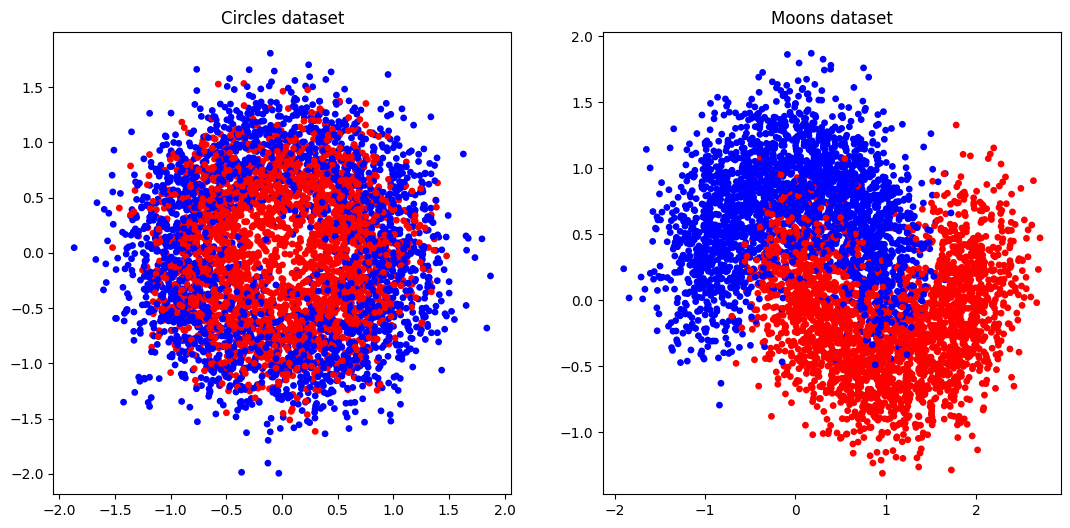

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='bwr', s=15)
axes[0].set_title("Circles dataset")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='bwr', s=15)
axes[1].set_title("Moons dataset")

plt.show()


**Circles metrics**

In [48]:
r = np.sqrt(X_circles[:, 0]**2 + X_circles[:, 1]**2)

r0 = r[y_circles == 0]
r1 = r[y_circles == 1]

hist_bins = 100
p0, bins = np.histogram(r0, bins=hist_bins, density=True)
p1, _ = np.histogram(r1, bins=bins, density=True)

bin_width = bins[1] - bins[0]
overlap = np.sum(np.minimum(p0, p1)) * bin_width

bayes_error = 0.5 * overlap
bayes_accuracy = 1 - bayes_error

r_threshold = (r0.mean() + r1.mean()) / 2
margin = np.abs(r - r_threshold)

mean_margin = margin.mean()
std_margin = margin.std()
near_boundary_ratio = np.mean(margin < 0.1)

var0 = np.var(r0)
var1 = np.var(r1)

fisher_ratio = (r0.mean() - r1.mean())**2 / (var0 + var1)

metrics_df = pd.DataFrame({
    "radial_overlap": [overlap],
    "bayes_error_approx": [bayes_error],
    "bayes_accuracy_upper_bound": [bayes_accuracy],
    "mean_margin": [mean_margin],
    "std_margin": [std_margin],
    "near_boundary_fraction_<0.1": [near_boundary_ratio],
    "class0_radial_variance": [var0],
    "class1_radial_variance": [var1],
    "fisher_ratio": [fisher_ratio]
})

metrics_df.index = ["Circles_distribution_metrics"]
metrics_df = metrics_df.T

metrics_df

,Circles_distribution_metrics
radial_overlap,0.615179
bayes_error_approx,0.307589
bayes_accuracy_upper_bound,0.692411
mean_margin,0.254597
std_margin,0.187073
near_boundary_fraction_<0.1,0.237600
class0_radial_variance,0.081386
class1_radial_variance,0.079419
fisher_ratio,0.482906


**Moons metrics** 

In [49]:
from sklearn.neighbors import KernelDensity
from sklearn.svm import SVC


svm_rbf = SVC(kernel='rbf', gamma='scale', probability=True)
svm_rbf.fit(X_moons_train, y_moons_train)

margin = np.abs(svm_rbf.decision_function(X_circles))  # np.abs для расстояния до границы

def kde_overlap(X, y, bandwidth=0.2, grid_size=100):
    X0 = X[y == 0]
    X1 = X[y == 1]

    kde0 = KernelDensity(bandwidth=bandwidth).fit(X0)
    kde1 = KernelDensity(bandwidth=bandwidth).fit(X1)

    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size)
    )
    grid = np.vstack([xx.ravel(), yy.ravel()]).T

    p0 = np.exp(kde0.score_samples(grid))
    p1 = np.exp(kde1.score_samples(grid))

    overlap = np.sum(np.minimum(p0, p1)) / grid_size**2
    return overlap

overlap = kde_overlap(X_moons, y_moons)


bayes_error = 0.5 * overlap
bayes_accuracy = 1 - bayes_error


mean_margin = margin.mean()
std_margin = margin.std()
near_boundary_ratio = np.mean(margin < 0.1)

var0_x = np.var(X_circles[y_circles==0,0])
var0_y = np.var(X_circles[y_circles==0,1])
var1_x = np.var(X_circles[y_circles==1,0])
var1_y = np.var(X_circles[y_circles==1,1])

mean0 = X_circles[y_circles==0].mean(axis=0)
mean1 = X_circles[y_circles==1].mean(axis=0)
fisher_ratio = np.sum((mean0 - mean1)**2) / (var0_x+var0_y+var1_x+var1_y)


metrics_df_moons = pd.DataFrame({
    "kde_overlap": [overlap],
    "bayes_error_approx": [bayes_error],
    "bayes_accuracy_upper_bound": [bayes_accuracy],
    "mean_margin": [mean_margin],
    "std_margin": [std_margin],
    "near_boundary_fraction_<0.1": [near_boundary_ratio],
    "class0_variance_sum": [var0_x + var0_y],
    "class1_variance_sum": [var1_x + var1_y],
    "fisher_ratio": [fisher_ratio]
})

metrics_df_moons.index = ["Moons_distribution_metrics"]
metrics_df_moons_T = metrics_df_moons.T
metrics_df_moons_T

,Moons_distribution_metrics
kde_overlap,0.015906
bayes_error_approx,0.007953
bayes_accuracy_upper_bound,0.992047
mean_margin,0.939385
std_margin,0.468910
near_boundary_fraction_<0.1,0.041800
class0_variance_sum,1.175821
class1_variance_sum,0.668441
fisher_ratio,0.000037


### Variational Quantum Classifiers

**Circles**

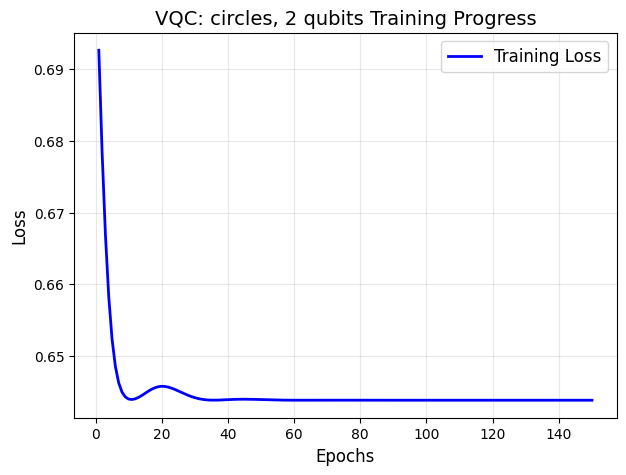

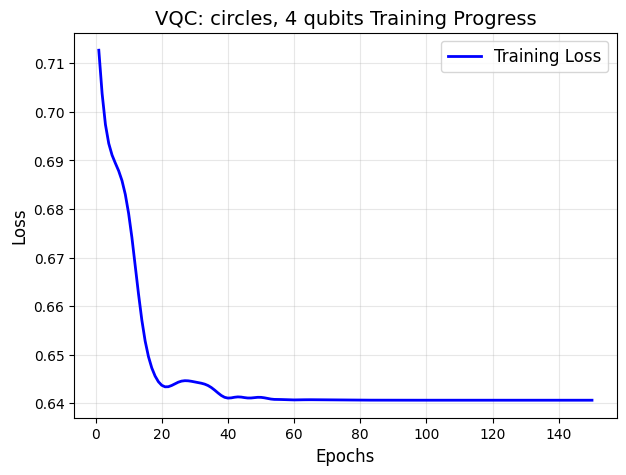

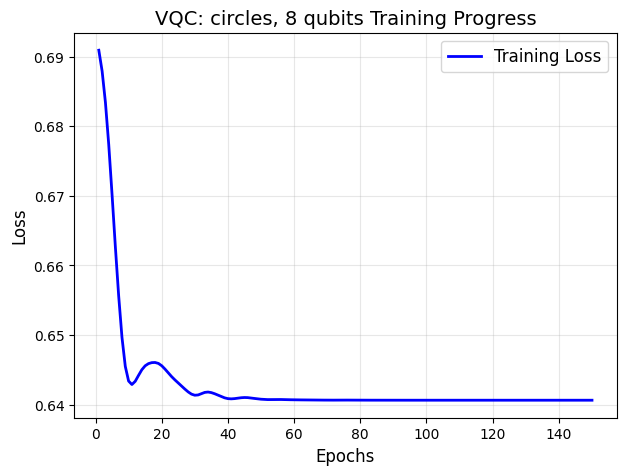

In [50]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_circles = VQC(n_qubits=q)

    losses = vqc_circles.fit(X_circles_train, y_circles_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_circles, X_circles_train, y_circles_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC",
        "Dataset": "Circles",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'VQC: circles, {q} qubits Training Progress')

**Moons**

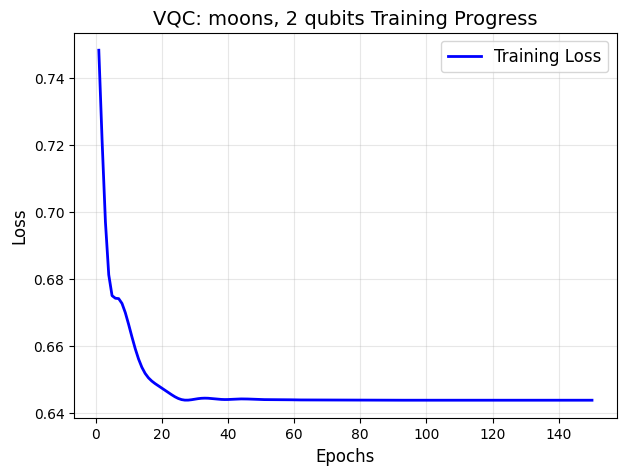

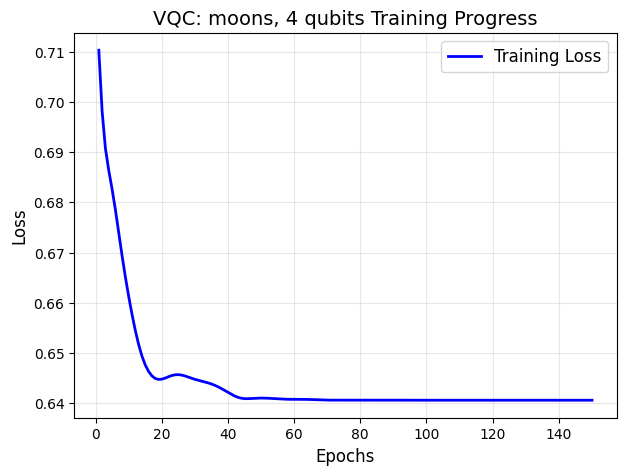

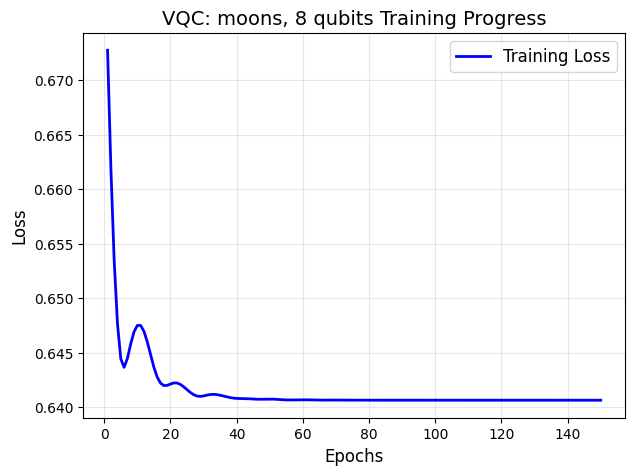

In [51]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_moons = VQC(n_qubits=q)

    losses = vqc_moons.fit(X_moons_train, y_moons_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_moons, X_moons_train, y_moons_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC",
        "Dataset": "Moons",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'VQC: moons, {q} qubits Training Progress')


### Hybrid Variational Quantum Classifiers

**Circles** 

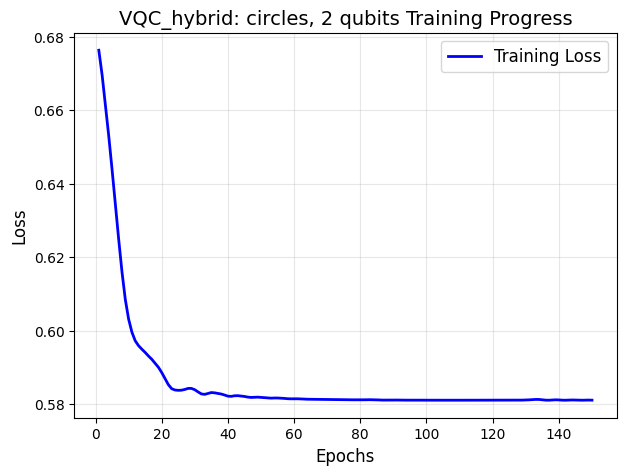

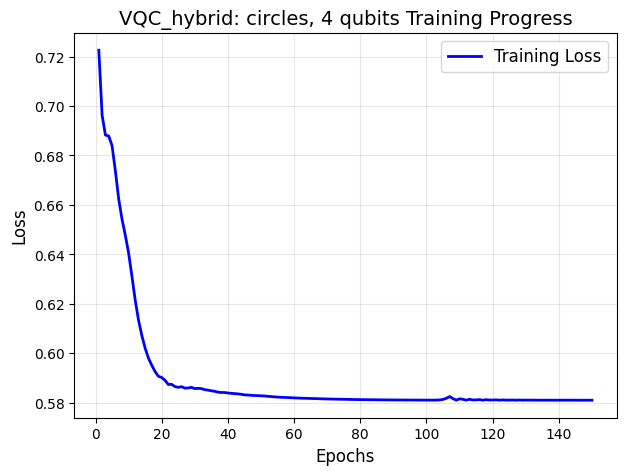

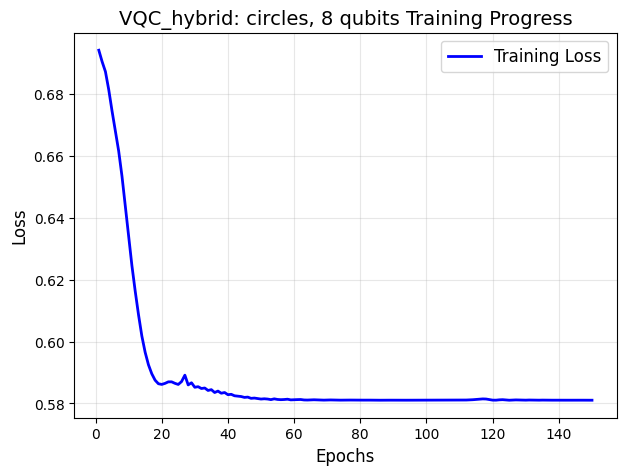

In [52]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_hybrid_circles = VQC_hybrid(n_qubits=q)

    losses = vqc_hybrid_circles.fit(X_circles_train, y_circles_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_hybrid_circles, X_circles_train, y_circles_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC_hybrid",
        "Dataset": "Circles",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'VQC_hybrid: circles, {q} qubits Training Progress')

**Moons**

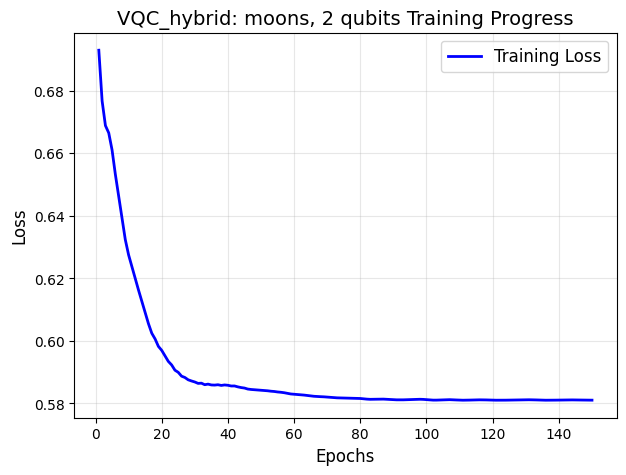

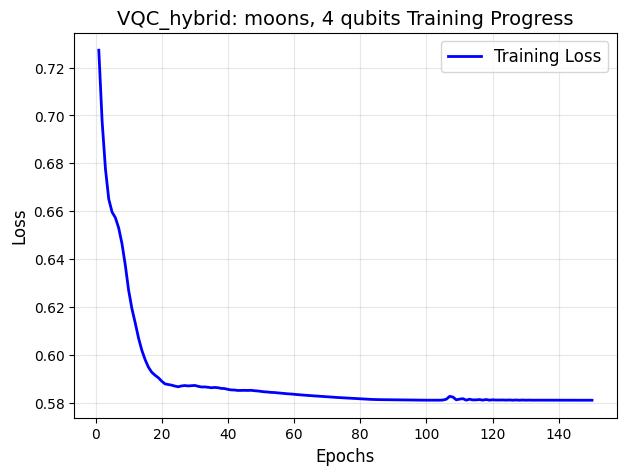

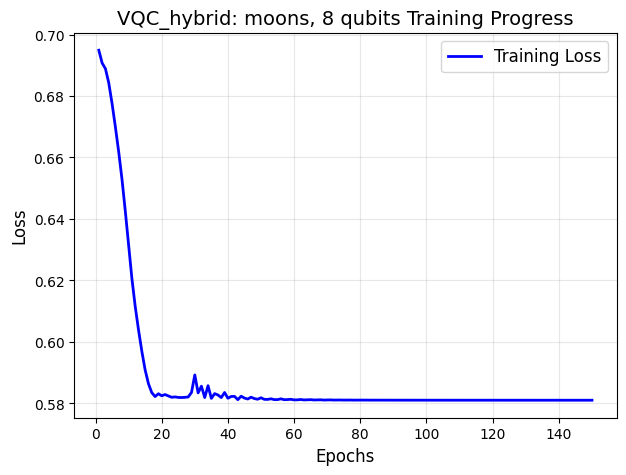

In [53]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_hybrid_moons = VQC_hybrid(n_qubits=q)

    losses = vqc_hybrid_moons.fit(X_moons_train, y_moons_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_hybrid_moons, X_moons_train, y_moons_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC_hybrid",
        "Dataset": "Moons",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'VQC_hybrid: moons, {q} qubits Training Progress')

### MLP

**Circles**

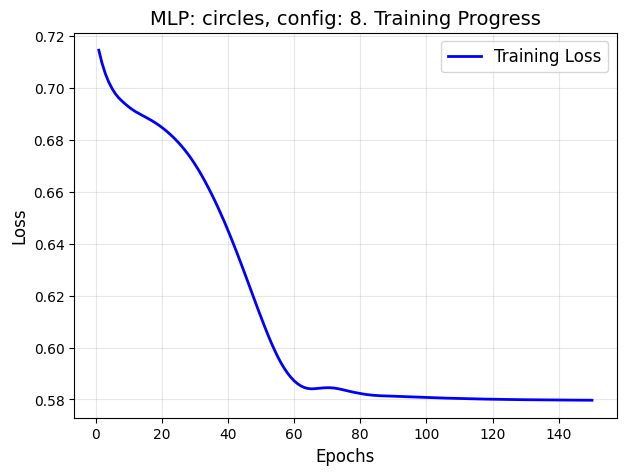

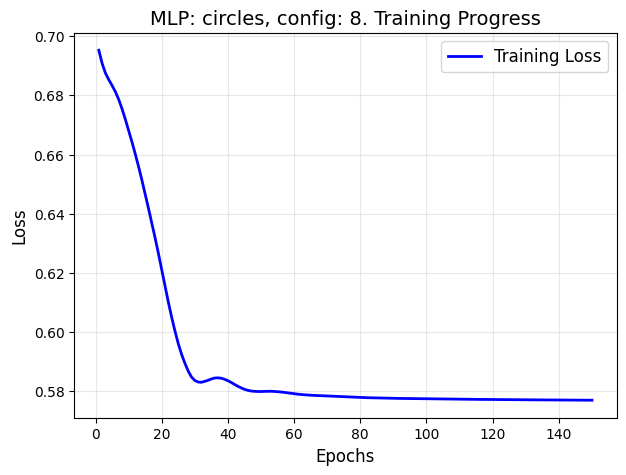

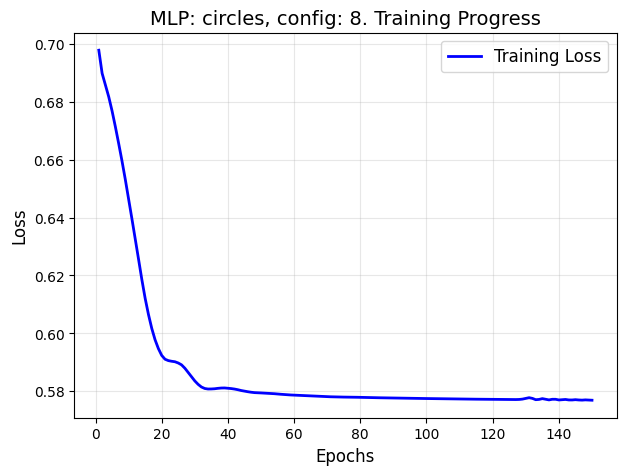

In [54]:
mlp_configs = [
    [8, 8],      # 2 слоя по 8 нейронов
    [16, 16],    # 2 слоя по 16 нейронов
    [32, 32]     # 2 слоя по 32 нейронов
]


for config in mlp_configs:
    mlp_circles = MLP(input_dim=X_circles_train.shape[1], hidden_dims=config)

    losses = mlp_circles.fit(X_circles_train, y_circles_train, epochs=150)

    grads, grad_norm, grad_var = compute_gradients(mlp_circles, X_circles_train, y_circles_train)
    grad_mean = grads.mean()


    results.append({
        "Model": "MLP",
        "Dataset": "Circles",
        "n_qubits": None,
        "Hidden_Layers": str(config),
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'MLP: circles, config: {q}. Training Progress')

**Moons**

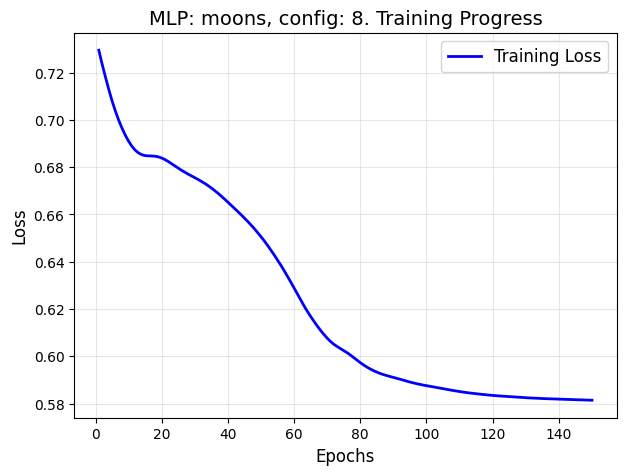

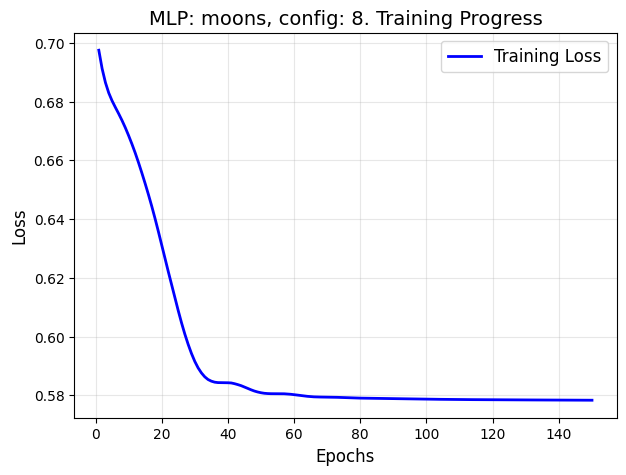

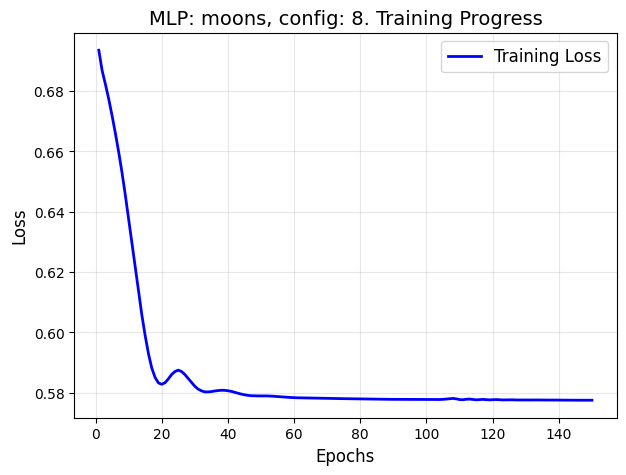

In [55]:
mlp_configs = [
    [8, 8],      # 2 слоя по 8 нейронов
    [16, 16],    # 2 слоя по 16 нейронов
    [32, 32]     # 2 слоя по 32 нейронов
]


for config in mlp_configs:
    mlp_moons = MLP(input_dim=X_moons_train.shape[1], hidden_dims=config)

    losses = mlp_moons.fit(X_moons_train, y_moons_train, epochs=150)

    grads, grad_norm, grad_var = compute_gradients(mlp_moons, X_moons_train, y_moons_train)
    grad_mean = grads.mean()


    results.append({
        "Model": "MLP",
        "Dataset": "Moons",
        "n_qubits": None,
        "Hidden_Layers": str(config),
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'MLP: moons, config: {q}. Training Progress')

### Analysis of the results

In [56]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by=["Dataset"]
)

df_results

,Model,Dataset,n_qubits,Hidden_Layers,Loss_final,Gradient_Norm,Gradient_Variance,Gradient_Mean
0,VQC,Circles,2.0,NaN,0.643854,0.000009,6.907041e-12,7.007524e-07
14,MLP,Circles,NaN,"[32, 32]",0.576921,0.024633,5.099916e-07,-4.980959e-05
13,MLP,Circles,NaN,"[16, 16]",0.576935,0.001610,7.662964e-09,7.052528e-06
12,MLP,Circles,NaN,"[8, 8]",0.579721,0.002030,3.867545e-08,-3.046494e-05
7,VQC_hybrid,Circles,4.0,NaN,0.581043,0.004066,4.065073e-07,-8.206542e-05
6,VQC_hybrid,Circles,2.0,NaN,0.581062,0.001358,8.216367e-08,9.766367e-05
8,VQC_hybrid,Circles,8.0,NaN,0.581044,0.004162,2.132192e-07,-5.715892e-05
2,VQC,Circles,8.0,NaN,0.640622,0.000028,1.605757e-11,-7.492939e-07
1,VQC,Circles,4.0,NaN,0.640622,0.000029,3.627689e-11,-5.858417e-07
4,VQC,Moons,4.0,NaN,0.640622,0.000036,5.600462e-11,1.279136e-06
